### 📝 Task info:
- **Domain:** Agriculture
- **Task:** Farmer Income Prediction (Regression)
- **Linear Algorithms:** Linear Regression (LR), Polynomial Regression (Poly), Ridge Regression, Lasso Regression
- **Non-Linear Algorithms:** K-Nearest Neighbors (KNN), Support Vector Machine (SVM/SVR), Decision Tree (DT), Random Forest (RF), XGBoost (XGB)
- **Note:** Optimized for fast parallel execution (`n_jobs=-1`)

### 💻 Code Work:

In [18]:
# Base Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect
from urllib.parse import quote_plus
import joblib


### 📤 0. Data Loading (from db load tables data as pandas df)
- Note: Load Validated Data

In [2]:
USER = "root"
PASSWORD = quote_plus("Annapurneswaraiah@403") 
HOST = "127.0.0.1" 
PORT = "3306"
DATABASE = "agricultural"

connection_url = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_url)

inspector = inspect(engine)
tables = inspector.get_table_names()
print("Available tables in MySQL:", tables)

if len(tables) > 0:
    table_name = tables[0] 
    print(f"\nLoading data from MySQL table: '{table_name}'...")
    df = pd.read_sql(f"SELECT * FROM `{table_name}`", con=engine)
    print(f"Success! Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
    display(df.head())
else:
    print("No tables found in the 'agricultural' database!")


Available tables in MySQL: ['agricultural_productivity', 'raw_agricultural_productivity_cleaned_v7.csv']

Loading data from MySQL table: 'agricultural_productivity'...
Success! Loaded 240,000 rows and 117 columns.


,record_id,state,lga,year,season,household_id,household_size,head_of_household_age,head_of_household_sex,head_of_household_education_level,...,group_type,access_to_improved_technologies,government_subsidy_received,subsidy_type,extension_worker_visit_last_6months,labor_hours_per_week_agriculture,hired_labor_used,women_decision_making_in_agriculture,child_labor_in_agriculture,child_labor_hours_per_week
0,1,Kebbi,Ogun_LGA_1,2018,wet,1,8,36.151305,Male,Unknown,...,No_group,0,0,None,0,20.684387,0,0,0,0.000000
1,2,Zamfara,Plateau_LGA_10,2018,wet,1,2,59.818008,Female,Unknown,...,No_group,0,0,None,1,12.296398,0,1,0,0.000000
2,3,Anambra,Rivers_LGA_9,2018,wet,1,9,57.055866,Male,Unknown,...,No_group,1,0,None,1,60.305280,0,1,1,0.412805
3,4,Sokoto,Lagos_LGA_8,2018,wet,1,6,54.137561,Female,Tertiary,...,No_group,0,0,None,0,59.165103,1,0,0,0.000000
4,5,Kebbi,Benue_LGA_4,2018,wet,1,11,57.980842,Female,Unknown,...,Association,1,0,None,0,8.739638,0,0,0,0.000000


### 👩🏻‍💻 1. Modeling

#### 🛠️ 1.1 Pre-Requisites

#### 🎯 1.1.1 X & y:
- Picking y output col for Predictive Modelling & considering remaining cols are X

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
target_col = 'total_household_income_ngn'
cat_cols = ['farming_system']
num_cols = [
    'head_of_household_age', 
    'land_owned_hectares', 
    'fertilizer_used_kg_per_hectare',
    'goats_number', 
    'sheep_number',
    'livestock_eggs_per_week', 
    'livestock_milk_litres_per_week'
]

X = df[cat_cols + num_cols].copy()
y = df[target_col].copy()

print(f"Features shape X: {X.shape}")
print(f"Target shape y:   {y.shape}")


Features shape X: (240000, 8)
Target shape y:   (240000,)


#### ✂️ 1.1.2 Train-Test Split:
- Dividing X & y data into train-test parts (80-20 split), train part for learning, test part for evaluation

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)


X_train shape: (192000, 8) y_train shape: (192000,)
X_test shape: (48000, 8) y_test shape: (48000,)


#### 🔄 1.1.3 Missing Values & Outliers Handling 
- for xtrain & xtest
    - Missing Values Identification & Handling (Mandatory)
    - Outlier Identification & Handling
- for ytrain and ytest: Filter na data for future predictions

In [ ]:
print("Missing values in X_train:\n", X_train.isnull().sum())
print("Missing values in y_train:\n", y_train.isnull().sum())

Missing values in X_train:
 farming_system                    0
head_of_household_age             0
land_owned_hectares               0
fertilizer_used_kg_per_hectare    0
goats_number                      0
sheep_number                      0
livestock_eggs_per_week           0
livestock_milk_litres_per_week    0
dtype: int64
Missing values in y_train:
 0


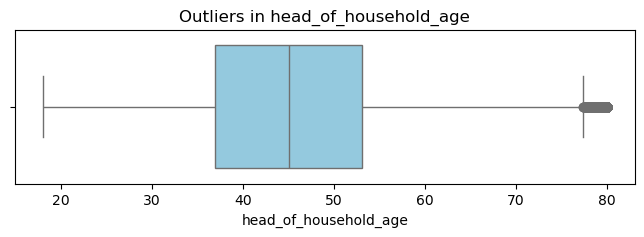

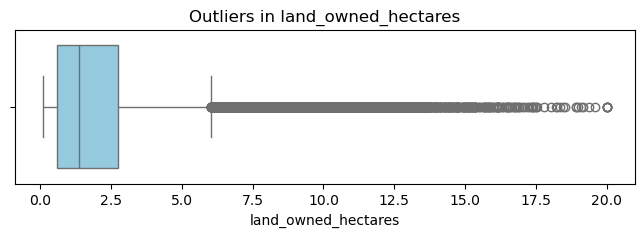

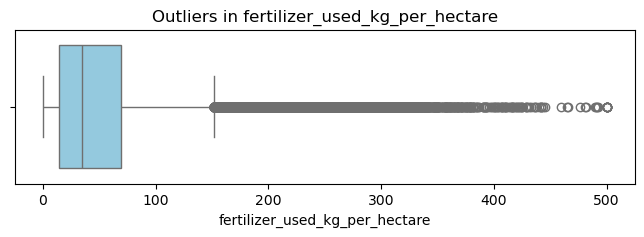

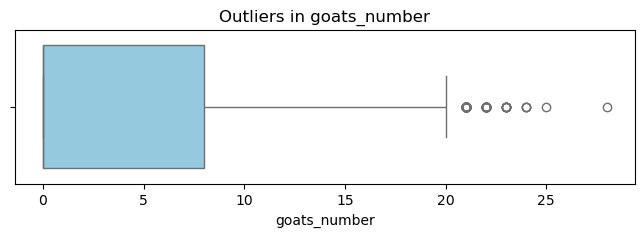

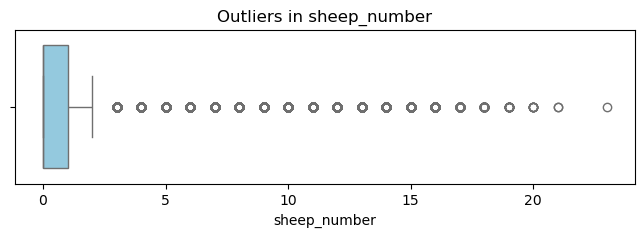

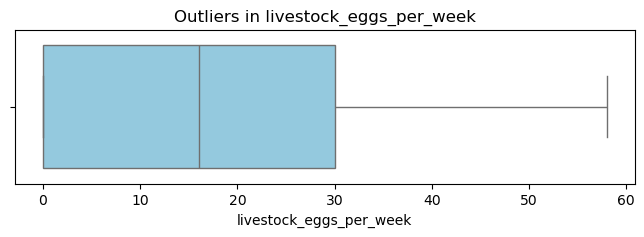

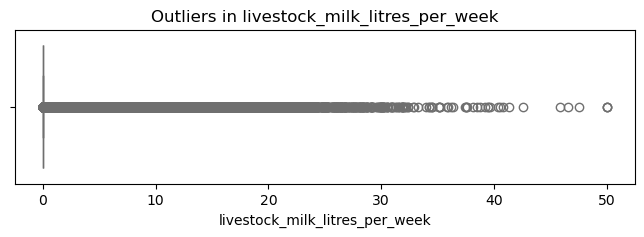

In [21]:
# 2. Outliers Visualization
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=X_train[col], color='skyblue')
    plt.title('Outliers in ' + col)
    plt.show()


#### ⚙️ 1.1.4 Feature Engineering of x for y
- **Feature Generation**
- **Feature Selection**
- **Feature Modification (Encoding & Scaling)**

#### 1. Feature Generation

In [ ]:

def create_features(df_input):
    df_feat = df_input.copy()
    df_feat['total_livestock_count'] = df_feat['goats_number'] + df_feat['sheep_number']
    df_feat['fertilizer_intensity'] = df_feat['fertilizer_used_kg_per_hectare'] / (df_feat['land_owned_hectares'] + 0.01)
    df_feat['weekly_animal_yield'] = df_feat['livestock_eggs_per_week'] + df_feat['livestock_milk_litres_per_week']
    df_feat['is_senior_farmer'] = np.where(df_feat['head_of_household_age'] >= 60, 1, 0)
    return df_feat
    X_train_fe = create_features(X_train)
    X_test_fe = create_features(X_test)

new_num_cols = num_cols + ['total_livestock_count', 'fertilizer_intensity', 'weekly_animal_yield', 'is_senior_farmer']


#### 2. Log Transformation for skewed features & target

In [ ]:

skewed_cols = ['land_owned_hectares', 'fertilizer_used_kg_per_hectare', 'fertilizer_intensity']
for col in skewed_cols:
    X_train_fe[col] = np.log1p(np.maximum(0, X_train_fe[col]))
    X_test_fe[col] = np.log1p(np.maximum(0, X_test_fe[col]))

y_train_log = np.log1p(np.maximum(0, y_train))
y_test_log = np.log1p(np.maximum(0, y_test))

#### 3. Categorical Encoding (OneHotEncoder)

In [ ]:

cat_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_encoded_cat = cat_encoder.fit_transform(X_train_fe[cat_cols])
X_test_encoded_cat = cat_encoder.transform(X_test_fe[cat_cols])

encoded_cat_cols = cat_encoder.get_feature_names_out(cat_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded_cat, columns=encoded_cat_cols, index=X_train_fe.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded_cat, columns=encoded_cat_cols, index=X_test_fe.index)

X_train_prep = pd.concat([X_train_fe[new_num_cols], X_train_encoded_df], axis=1)
X_test_prep = pd.concat([X_test_fe[new_num_cols], X_test_encoded_df], axis=1)


##### 4. Feature Scaling (StandardScaler)

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_prep)
X_test_scaled = scaler.transform(X_test_prep)

print("Preprocessed X_train shape:", X_train_scaled.shape)
print("Preprocessed X_test shape:", X_test_scaled.shape)

Preprocessed X_train shape: (192000, 13)
Preprocessed X_test shape: (48000, 13)


#### 🤖 1.2 Model + Define, Train & Study
- **Linear Algorithms:** LR, Poly, Ridge, Lasso
- **Non-Linear Algorithms:** KNN, SVM, DT, RF, XGB
- *Note:* `n_jobs=-1` uses all CPU cores for high-speed parallel training.

#### Define Linear & Non-Linear Models with Multi-Core Parallel Processing (n_jobs=-1)

In [ ]:

models = {
    "LR": LinearRegression(n_jobs=-1),
    "Poly": make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression(n_jobs=-1)),
    "Ridge": Ridge(alpha=0.01),
    "Lasso": Lasso(alpha=0.01),
    "KNN": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "SVM": SVR(C=1.0, kernel='rbf'),
    "DT": DecisionTreeRegressor(random_state=42),
    "RF": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    "XGB": XGBRegressor(n_estimators=50, learning_rate=0.1, random_state=42, n_jobs=-1)
}

# Train All Models
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_log) 
    trained_models[name] = model
    print(f"✅ Model {name} trained.")


✅ Model LR trained.
✅ Model Poly trained.
✅ Model Ridge trained.
✅ Model Lasso trained.
✅ Model KNN trained.
✅ Model SVM trained.
✅ Model DT trained.
✅ Model RF trained.
✅ Model XGB trained.


#### ✅ 1.3 Trained Model Predictions & Evaluations
- Predictions on Test Data
- Evaluation Metrics & Loss (RMSE & R²)
- Bias-Variance Tradeoff Analysis for All Models

In [9]:
results = []

for name, model in trained_models.items():
    # Predictions on train & test (log scale)
    pred_train_log = model.predict(X_train_scaled)
    pred_test_log = model.predict(X_test_scaled)
    
    # Back-transform to original scale for RMSE
    pred_train_orig = np.expm1(pred_train_log)
    pred_test_orig = np.expm1(pred_test_log)
    
    # Calculate RMSE on original scale
    train_rmse = np.sqrt(mean_squared_error(y_train, pred_train_orig))
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test_orig))
    
    # Calculate R² score on log scale
    train_r2 = r2_score(y_train_log, pred_train_log)
    test_r2 = r2_score(y_test_log, pred_test_log)
    
    # Determine Bias-Variance Fit
    if abs(train_r2 - test_r2) <= 0.05 and train_r2 >= 0.5:
        fit_status = "Goodfit"
    elif train_r2 - test_r2 > 0.05:
        fit_status = "Overfit"
    else:
        fit_status = "Underfit"
        
    results.append({
        "Models": name,
        "TrainLoss (RMSE)": round(train_rmse, 2),
        "TestLoss (RMSE)": round(test_rmse, 2),
        "TrainScore (R²)": round(train_r2, 4),
        "TestScore (R²)": round(test_r2, 4),
        "Bias-Variance (Fit)": fit_status
    })

# Final Evaluation Table
eval_df = pd.DataFrame(results)
display(eval_df)


,Models,TrainLoss (RMSE),TestLoss (RMSE),TrainScore (R²),TestScore (R²),Bias-Variance (Fit)
0,LR,348465.01,349797.35,0.1673,0.1670,Underfit
1,Poly,346032.18,347316.63,0.1804,0.1805,Underfit
2,Ridge,348465.01,349797.35,0.1673,0.1670,Underfit
3,Lasso,348326.24,349618.02,0.1664,0.1661,Underfit
4,KNN,312448.70,367985.84,0.3437,0.0194,Overfit
5,SVM,343940.63,348056.14,0.1873,0.1728,Underfit
6,DT,0.00,490746.17,1.0000,-0.6914,Overfit
7,RF,162573.04,353948.90,0.8730,0.1189,Overfit
8,XGB,343937.13,347116.29,0.1921,0.1817,Underfit


#### ✨ 1.4 Fast Hyperparameter Tuning
- Hyperparameter Tuning for top performing models with `n_jobs=-1` for fast execution.

In [10]:
# Fast Tuning for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train_log)
best_rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)
print("Best RF R² Score:", round(grid_rf.best_score_, 4))

# Fast Tuning for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1]
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), xgb_param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_log)
best_xgb = grid_xgb.best_estimator_
print("Best XGB Params:", grid_xgb.best_params_)
print("Best XGB R² Score:", round(grid_xgb.best_score_, 4))


Best RF Params: {'max_depth': 10, 'n_estimators': 100}
Best RF R² Score: 0.1795
Best XGB Params: {'learning_rate': 0.05, 'n_estimators': 100}
Best XGB R² Score: 0.1808


#### 📥 1.5 Saving model & Real Time Prediction
- Saving trained best model, scaler, and encoder
- Real-time prediction on new sample input

In [ ]:

best_model = best_rf if grid_rf.best_score_ >= grid_xgb.best_score_ else best_xgb

# 1. Save artifacts
joblib.dump(best_model, 'best_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(cat_encoder, 'encoder.pkl')
print("Best Model, Scaler, and Encoder saved successfully.")

# 2. Real Time Prediction Example
sample_data = pd.DataFrame([{
    'farming_system': 'Crop',
    'head_of_household_age': 45,
    'land_owned_hectares': 2.5,
    'fertilizer_used_kg_per_hectare': 50,
    'goats_number': 3,
    'sheep_number': 2,
    'livestock_eggs_per_week': 15,
    'livestock_milk_litres_per_week': 10
}])

sample_fe = create_features(sample_data)
for col in skewed_cols:
    sample_fe[col] = np.log1p(np.maximum(0, sample_fe[col]))

sample_cat = cat_encoder.transform(sample_fe[cat_cols])
sample_cat_df = pd.DataFrame(sample_cat, columns=encoded_cat_cols, index=sample_fe.index)
sample_prep = pd.concat([sample_fe[new_num_cols], sample_cat_df], axis=1)

sample_scaled = scaler.transform(sample_prep)
pred_log_income = best_model.predict(sample_scaled)
pred_income = np.expm1(pred_log_income)

print(f"Predicted Farmer Income: NGN {pred_income[0]:,.2f}")


Best Model, Scaler, and Encoder saved successfully.
Predicted Farmer Income: NGN 741,954.12


c:\Users\asus\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
